In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Setting Styles for our Plots and Visualizations

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12



In [254]:
# Loading Amazon products dataset
df = pd.read_csv('amazon.csv')

In [255]:
# Amazon products sales EDA
df.head()
df.info()
df.shape
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [256]:
# Checking for duplicates and missing values in the dataset
df.duplicated().sum()
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [257]:
# Encoding the dataset

try:
    df = pd.read_csv('amazon.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('amazon.csv', encoding='latin-1')

print(df['discounted_price'].head())
print(df.shape)

0    ₹399
1    ₹199
2    ₹199
3    ₹329
4    ₹154
Name: discounted_price, dtype: str
(1465, 16)


In [258]:
df.info()

print(df[['discounted_price', 'actual_price', 'discount_percentage']].head())

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB
 

In [259]:
# Cleaning the price columns from strings to floats

def parse_price(s):
    if pd.isna(s): return None
    return float(str(s).replace('₹', '').replace(',', '').strip())

df['discounted_price'] = df['discounted_price'].apply(parse_price)
df['actual_price']     = df['actual_price'].apply(parse_price)

print(df[['discounted_price', 'actual_price']].head())
print(df[['discounted_price', 'actual_price']].dtypes)

   discounted_price  actual_price
0             399.0        1099.0
1             199.0         349.0
2             199.0        1899.0
3             329.0         699.0
4             154.0         399.0
discounted_price    float64
actual_price        float64
dtype: object


In [260]:
# Cleaning the strings from the product ratings and rating counts, and converting them to numeric types

df['rating'] = (
    df['rating']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .apply(pd.to_numeric, errors='coerce')
)

df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',', '', regex=False)
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

print(df[['discount_percentage', 'rating', 'rating_count']].head())
print(df[['discount_percentage', 'rating', 'rating_count']].dtypes)

  discount_percentage  rating  rating_count
0                 64%     4.2         24269
1                 43%     4.0         43994
2                 90%     3.9          7928
3                 53%     4.2         94363
4                 61%     4.2         16905
discount_percentage        str
rating                 float64
rating_count             Int64
dtype: object


In [261]:
# splitting the category column into main and sub categories, and cleaning the strings

cat_split = df['category'].astype(str).str.split('|', expand=True)

df['main_category'] = cat_split[0].str.replace('&', ' & ', regex=False)
df['sub_category'] = (
    df['category']
    .astype(str)
    .str.rsplit('|', n=1)
    .str[-1]
    .str.replace('&', ' & ', regex=False)
    .str.replace(r'(?<=[a-z0-9])(?=[A-Z])', ' ', regex=True)
    .str.replace(r'(?<=[A-Z])(?=[A-Z][a-z])', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print(df[['main_category', 'sub_category']].head())
print("\n=== Unique Categories ===")
print(df['main_category'].value_counts())
print("\n=== Unique Sub Categories ===")
print(df['sub_category'].value_counts())

             main_category sub_category
0  Computers & Accessories   USB Cables
1  Computers & Accessories   USB Cables
2  Computers & Accessories   USB Cables
3  Computers & Accessories   USB Cables
4  Computers & Accessories   USB Cables

=== Unique Categories ===
main_category
Electronics                526
Computers & Accessories    453
Home & Kitchen             448
OfficeProducts              31
MusicalInstruments           2
HomeImprovement              2
Toys & Games                 1
Car & Motorbike              1
Health & PersonalCare        1
Name: count, dtype: int64

=== Unique Sub Categories ===
sub_category
USB Cables                 233
Smart Watches               76
Smartphones                 68
Smart Televisions           63
In-Ear                      52
                          ... 
Roti Makers                  1
Fan Parts & Accessories      1
Stand Mixers                 1
Pedestal Fans                1
Handheld Bags                1
Name: count, Length: 207, dty

In [262]:
df['main_category'] = (df['main_category']
    .str.replace('OfficeProducts', 'Office Products')
    .str.replace('MusicalInstruments', 'Musical Instruments')
    .str.replace('HomeImprovement', 'Home Improvement')
    .str.replace('PersonalCare', 'Personal Care')
)

print(df['main_category'].value_counts())

main_category
Electronics                526
Computers & Accessories    453
Home & Kitchen             448
Office Products             31
Musical Instruments          2
Home Improvement             2
Toys & Games                 1
Car & Motorbike              1
Health & Personal Care       1
Name: count, dtype: int64


In [263]:
#CREATING A SEPARATE TABLE FOR REVIEWS

reviews = df[['product_id', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content']].copy()

for col in ['user_id', 'user_name', 'review_id', 'review_title', 'review_content']:
    reviews[col] = reviews[col].str.split(',')

reviews = reviews.explode('user_id').reset_index(drop=True)

for col in ['user_name', 'review_id', 'review_title', 'review_content']:
    reviews[col] = reviews[col].explode().reset_index(drop=True)

for col in ['user_id', 'user_name', 'review_id', 'review_title', 'review_content']:
    reviews[col] = reviews[col].str.strip()

df = df.drop(columns=['user_id', 'user_name', 'review_id', 'review_title', 'review_content'])


In [264]:
print(reviews.to_string(max_rows= 10))


       product_id                       user_id        user_name       review_id                                        review_title                                                                        review_content
0      B07JW9H4J1  AG3D6O4STAQKAY2UVGEUV46KN35Q            Manav  R3HXWT0LRP0NMF                                           Satisfied                                        Looks durable Charging is fine tooNo complains
1      B07JW9H4J1  AHMY5CWJMMK5BJRBBSNLYT3ONILA     Adarsh gupta  R2AJM3LFTLZHFO                             Charging is really fast                                                               Charging is really fast
2      B07JW9H4J1  AHCTC6ULH4XB6YHDY6PCH2R772LQ          Sundeep    R6AQJGUP6P86                                     Value for money                                                                         good product.
3      B07JW9H4J1  AGYHHIERNXKA6P5T7CZLXKVPT7IQ   S.Sayeed Ahmed  R1KD19VHEDV0OR                                      Produc

In [265]:
# Dropping columns that are not needed for analysis

df = df.drop(columns=['category', 'img_link', 'product_link'])

print(df.columns.tolist())
print(f"Remaining columns: {len(df.columns)}")

['product_id', 'product_name', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'main_category', 'sub_category']
Remaining columns: 10


In [266]:
print(df['discount_percentage'].dtype)
print(df['discount_percentage'].head())

df['discount_percentage'] = (df['discount_percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float) / 100
)

# Futher and feature engineering

df['savings_INR'] = df['actual_price'] - df['discounted_price']
df['weighted_rating'] = df['rating'] * np.log1p(df['rating_count'])
df['deal_score'] = df['discount_percentage'] * df['rating']

df['price_tier'] = pd.cut(
    df['discounted_price'],
    bins=[0, 199, 499, 999, np.inf],
    labels=['Budget', 'Mid', 'Premium', 'Luxury']
)

print(df[['savings_INR', 'weighted_rating', 'deal_score', 'price_tier']].head(10))
print("\n=== Price tier distribution ===")
print(df['price_tier'].value_counts())

str
0    64%
1    43%
2    90%
3    53%
4    61%
Name: discount_percentage, dtype: str
   savings_INR  weighted_rating  deal_score price_tier
0       700.00        42.407384       2.688        Mid
1       150.00        42.767325       1.720     Budget
2      1700.00        35.015301       3.510     Budget
3       370.00        48.110643       2.226        Mid
4       245.00         40.88878       2.562     Budget
5       851.00        39.473842       3.315     Budget
6       322.37         39.47614       2.665     Budget
7        70.00        44.387148       0.989        Mid
8       500.00        50.815798       2.100        Mid
9       100.00        42.767325       1.320     Budget

=== Price tier distribution ===
price_tier
Luxury     637
Mid        377
Premium    252
Budget     199
Name: count, dtype: int64


In [267]:
# Data Validation and Verification

# Check dtypes

print("=== Data types ===")
print(df.dtypes)

# Check for any new nulls introduced during feature engineering

print("\n=== Null check after feature engineering ===")
print(df.isnull().sum())

print("\n=== Value ranges ===")
print(df[['discounted_price', 'actual_price',
        'savings_INR', 'rating',
        'deal_score', 'weighted_rating']].describe())

=== Data types ===
product_id                  str
product_name                str
discounted_price        float64
actual_price            float64
discount_percentage     float64
rating                  float64
rating_count              Int64
about_product               str
main_category               str
sub_category             object
savings_INR             float64
weighted_rating         Float64
deal_score              float64
price_tier             category
dtype: object

=== Null check after feature engineering ===
product_id             0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
main_category          0
sub_category           0
savings_INR            0
weighted_rating        3
deal_score             1
price_tier             0
dtype: int64

=== Value ranges ===
       discounted_price   actual_price   savings_INR       rating  \
count       1465.00

In [268]:
# Handling any remaining nulls in rating and rating_count by filling with median values, and recalculating weighted_rating and deal_score

df['rating'] = df['rating'].fillna(df['rating'].median())

df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

df['weighted_rating'] = df['rating'] * np.log1p(df['rating_count'])
df['deal_score']      = df['discount_percentage'] * df['rating']

print("=== Null check after fix ===")
print(df.isnull().sum())

=== Null check after fix ===
product_id             0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
main_category          0
sub_category           0
savings_INR            0
weighted_rating        0
deal_score             0
price_tier             0
dtype: int64


In [269]:
# Encoding the categorical columns for potential machine learning applications

df['price_tier'] = pd.cut(
    df['discounted_price'],
    bins=[0, 500, 2000, 10000, np.inf],
    labels=['Budget', 'Mid', 'Premium', 'Luxury']
)

print(df['price_tier'].value_counts())

le = LabelEncoder()
df['main_category_enc'] = le.fit_transform(df['main_category'])

df['sub_category_enc'] = le.fit_transform(df['sub_category'])

oe = OrdinalEncoder(categories=[['Budget', 'Mid', 'Premium', 'Luxury']])
df['price_tier_enc'] = oe.fit_transform(df[['price_tier']])


print("=== Encoded columns ===")
print(df[['main_category', 'main_category_enc',
        'sub_category', 'sub_category_enc',
        'price_tier', 'price_tier_enc']].head(10))

print("\n=== Main category mapping ===")
for i, cat in enumerate(le.classes_):
    print(f"{i} → {cat}")

price_tier
Budget     576
Mid        527
Premium    240
Luxury     122
Name: count, dtype: int64
=== Encoded columns ===
             main_category  main_category_enc           sub_category  \
0  Computers & Accessories                  1             USB Cables   
1  Computers & Accessories                  1             USB Cables   
2  Computers & Accessories                  1             USB Cables   
3  Computers & Accessories                  1             USB Cables   
4  Computers & Accessories                  1             USB Cables   
5  Computers & Accessories                  1             USB Cables   
6  Computers & Accessories                  1             USB Cables   
7  Computers & Accessories                  1             USB Cables   
8  Computers & Accessories                  1  Wireless USB Adapters   
9  Computers & Accessories                  1             USB Cables   

   sub_category_enc price_tier  price_tier_enc  
0               190     Budget       

In [270]:
# Final columns and data preview check_link

print("=== Final dataframe columns ===")
print(df.columns.tolist())

print("\n=== Shape ===")
print(df.shape)

print("\n=== First 5 rows of numeric columns only ===")
print(df[['discounted_price', 'actual_price', 'discount_percentage',
        'rating', 'rating_count', 'savings_INR', 'weighted_rating',
        'deal_score', 'main_category_enc', 'sub_category_enc',
        'price_tier_enc']].head())

=== Final dataframe columns ===
['product_id', 'product_name', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'main_category', 'sub_category', 'savings_INR', 'weighted_rating', 'deal_score', 'price_tier', 'main_category_enc', 'sub_category_enc', 'price_tier_enc']

=== Shape ===
(1465, 17)

=== First 5 rows of numeric columns only ===
   discounted_price  actual_price  discount_percentage  rating  rating_count  \
0             399.0        1099.0                 0.64     4.2         24269   
1             199.0         349.0                 0.43     4.0         43994   
2             199.0        1899.0                 0.90     3.9          7928   
3             329.0         699.0                 0.53     4.2         94363   
4             154.0         399.0                 0.61     4.2         16905   

   savings_INR  weighted_rating  deal_score  main_category_enc  \
0        700.0        42.407384       2.688                  1

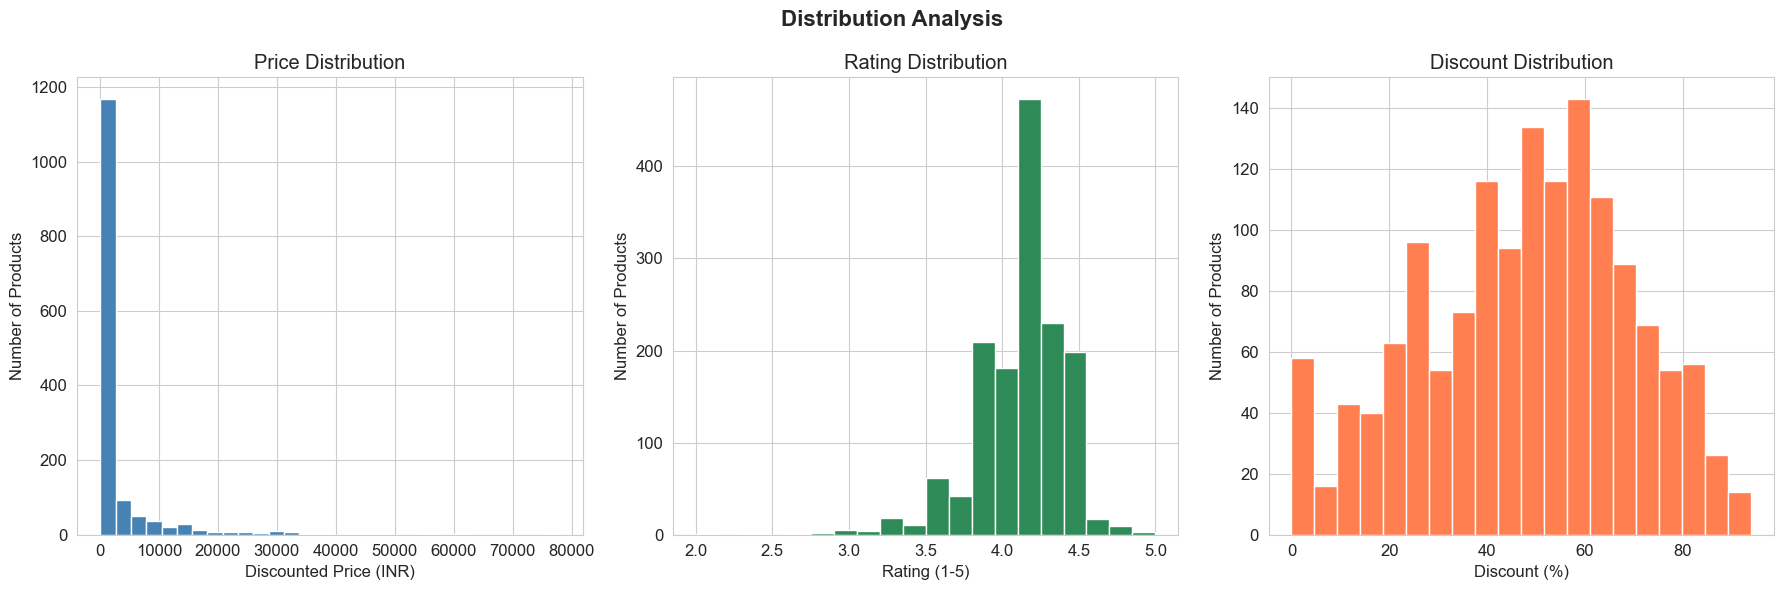

In [271]:
# Visualization and EDA

# a). Distribution Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution Analysis', fontsize=16, fontweight='bold')

# Price Distribution

axes[0].hist(df['discounted_price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Discounted Price (INR)')
axes[0].set_ylabel('Number of Products')

# Rating Distribution

axes[1].hist(df['rating'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating (1-5)')
axes[1].set_ylabel('Number of Products')

# Discount Distribution

axes[2].hist(df['discount_percentage'] * 100, bins=20, color='coral', edgecolor='white')
axes[2].set_title('Discount Distribution')
axes[2].set_xlabel('Discount (%)')
axes[2].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()



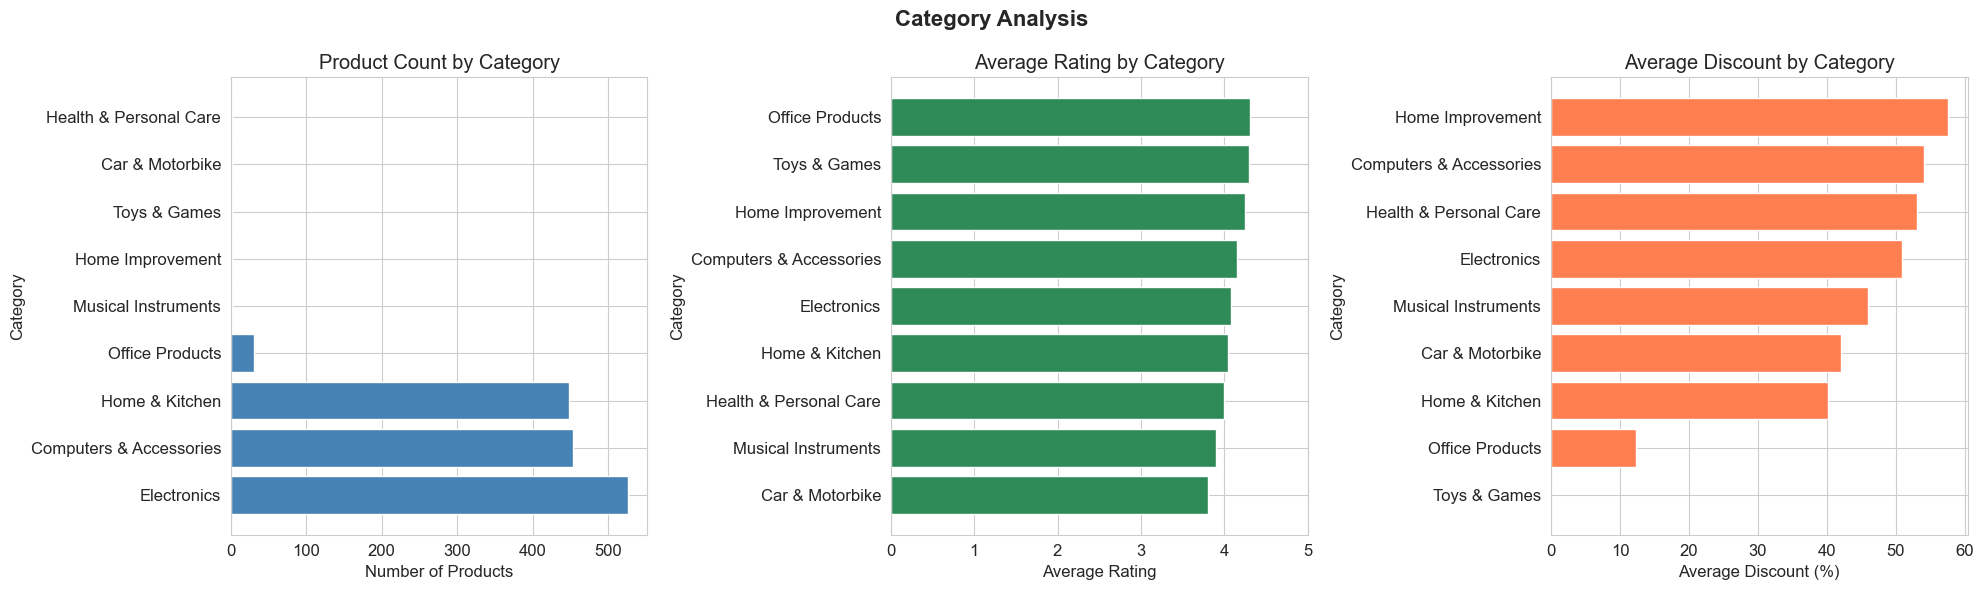

In [272]:
# b). Category Analysis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Category Analysis', fontsize=16, fontweight='bold')

# Product count by category
category_counts = df['main_category'].value_counts()
axes[0].barh(category_counts.index, category_counts.values, color='steelblue')
axes[0].set_title('Product Count by Category')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Category')

# Average rating by category
avg_rating = df.groupby('main_category')['rating'].mean().sort_values()
axes[1].barh(avg_rating.index, avg_rating.values, color='seagreen')
axes[1].set_title('Average Rating by Category')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Category')
axes[1].set_xlim(0, 5)

# Average discount by category
avg_discount = df.groupby('main_category')['discount_percentage'].mean().sort_values() * 100
axes[2].barh(avg_discount.index, avg_discount.values, color='coral')
axes[2].set_title('Average Discount by Category')
axes[2].set_xlabel('Average Discount (%)')
axes[2].set_ylabel('Category')

plt.tight_layout()
plt.show()

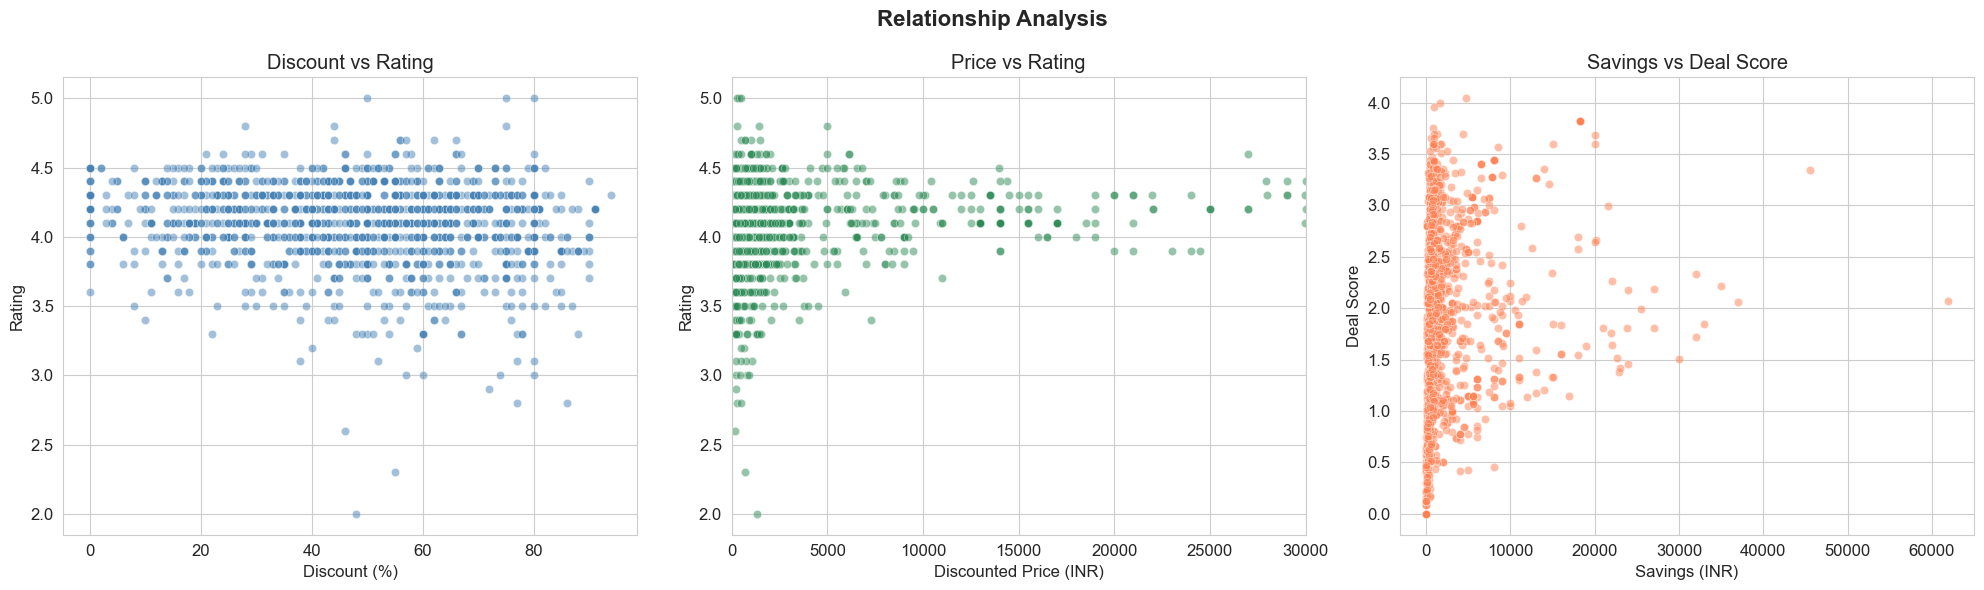

In [273]:
# c). Relationship Analysis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Relationship Analysis', fontsize=16, fontweight='bold')

# Discount vs Rating
axes[0].scatter(df['discount_percentage'] * 100, df['rating'], 
                alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
axes[0].set_title('Discount vs Rating')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Rating')

# Price vs Rating
axes[1].scatter(df['discounted_price'], df['rating'],
                alpha=0.5, color='seagreen', edgecolors='white', linewidth=0.5)
axes[1].set_title('Price vs Rating')
axes[1].set_xlabel('Discounted Price (INR)')
axes[1].set_ylabel('Rating')
axes[1].set_xlim(0, 30000)

# Savings vs Deal Score
axes[2].scatter(df['savings_INR'], df['deal_score'],
                alpha=0.5, color='coral', edgecolors='white', linewidth=0.5)
axes[2].set_title('Savings vs Deal Score')
axes[2].set_xlabel('Savings (INR)')
axes[2].set_ylabel('Deal Score')

plt.tight_layout()
plt.show()

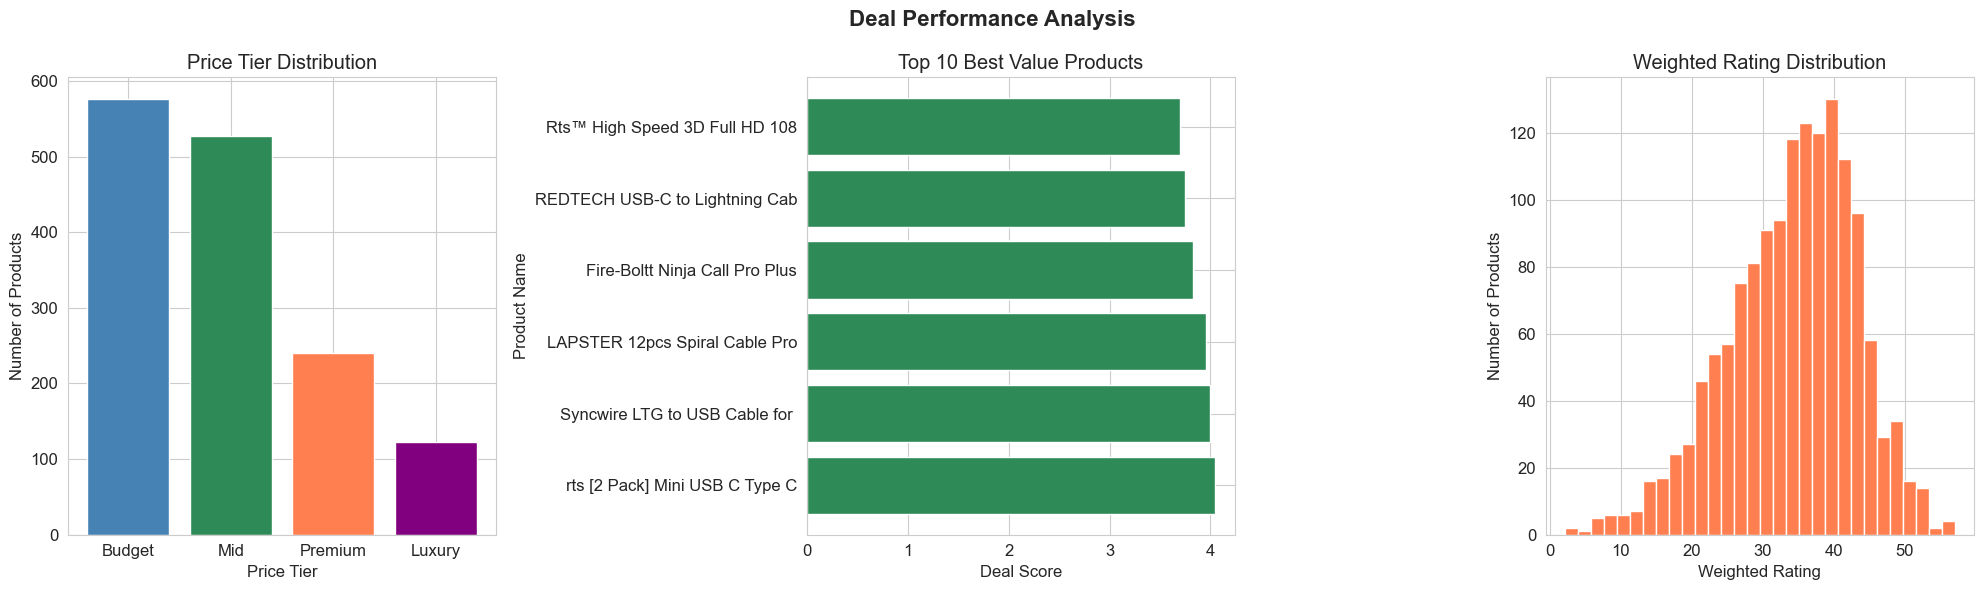

In [274]:
# d). Deal Performance Analysis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Deal Performance Analysis', fontsize=16, fontweight='bold')

# Price tier distribution
price_tier_counts = df['price_tier'].value_counts()
axes[0].bar(price_tier_counts.index, price_tier_counts.values, 
            color=['steelblue', 'seagreen', 'coral', 'purple'], edgecolor='white')
axes[0].set_title('Price Tier Distribution')
axes[0].set_xlabel('Price Tier')
axes[0].set_ylabel('Number of Products')

# Top 10 best value products
top10 = df.nlargest(10, 'deal_score')[['product_name', 'deal_score']]
top10['product_name'] = top10['product_name'].str[:30]  # truncate long names
axes[1].barh(top10['product_name'], top10['deal_score'], color='seagreen', edgecolor='white')
axes[1].set_title('Top 10 Best Value Products')
axes[1].set_xlabel('Deal Score')
axes[1].set_ylabel('Product Name')

# Weighted rating distribution
axes[2].hist(df['weighted_rating'], bins=30, color='coral', edgecolor='white')
axes[2].set_title('Weighted Rating Distribution')
axes[2].set_xlabel('Weighted Rating')
axes[2].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

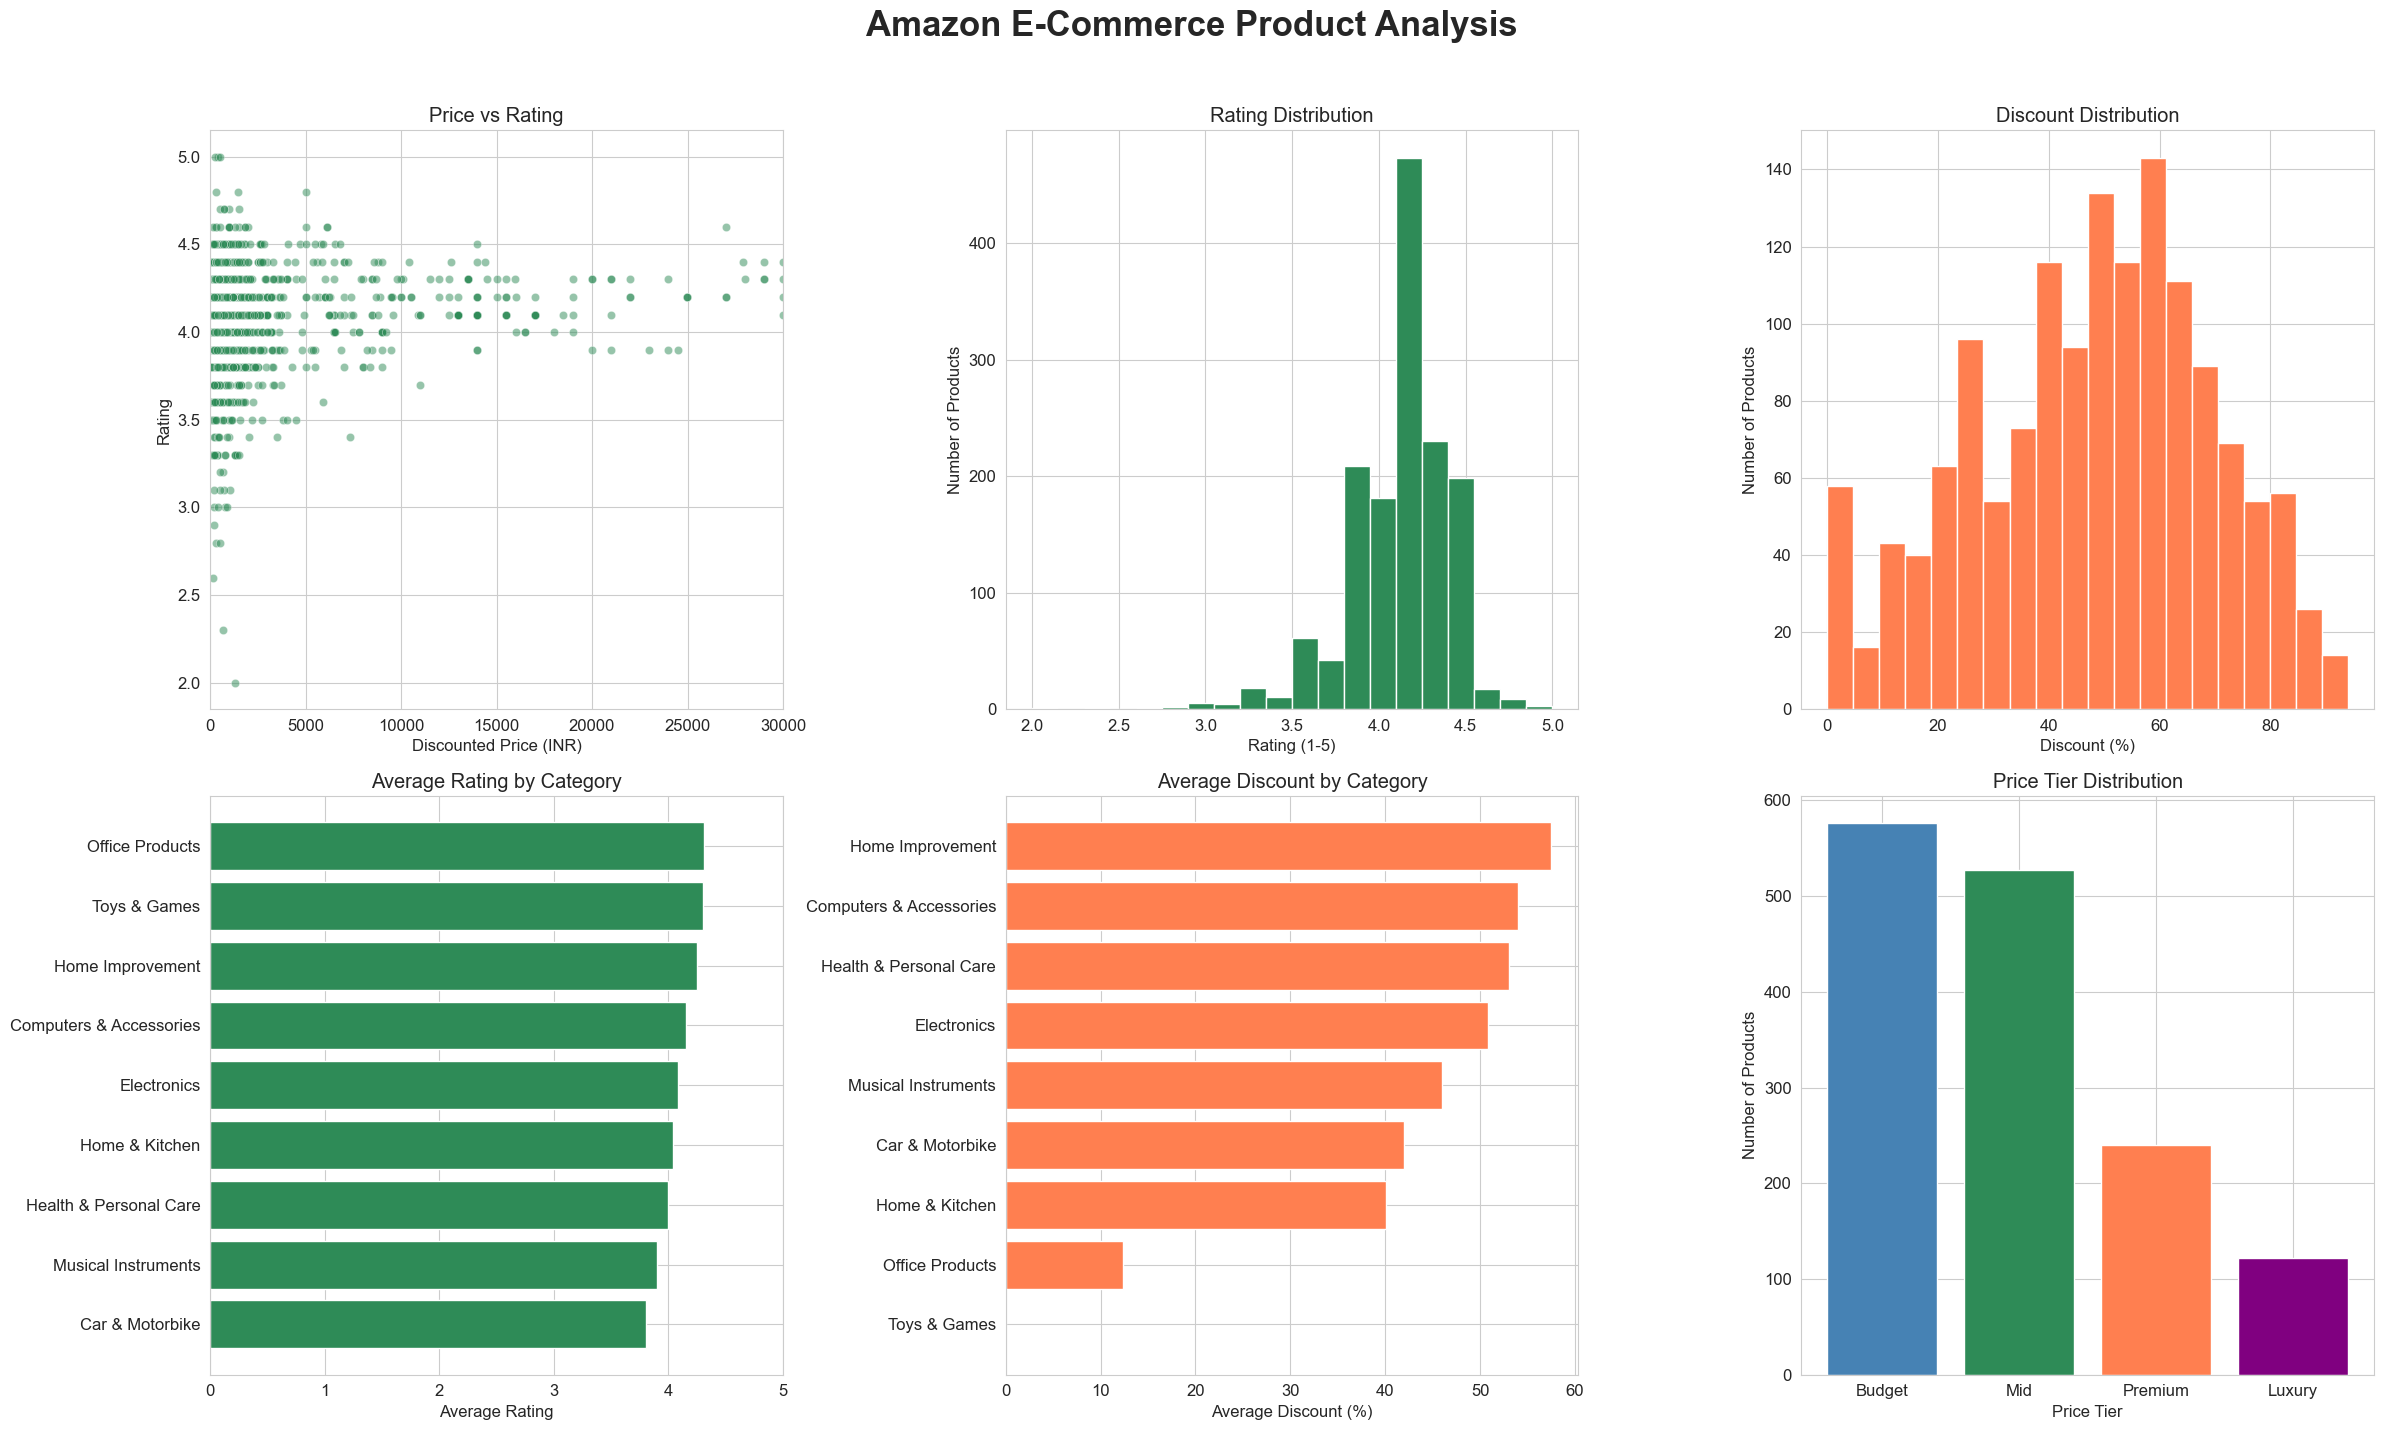

In [284]:
# AMAZON E-COMMERCE PRODUCT ANALYSIS DASHBOARD

fig = plt.figure(figsize=(24, 14))
fig.suptitle('Amazon E-Commerce Product Analysis', fontsize=25, fontweight='bold', y=1.02)

# Row 1: Distribution Analysis


# Price vs Rating
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(df['discounted_price'], df['rating'],
            alpha=0.5, color='seagreen', edgecolors='white', linewidth=0.5)
ax1.set_title('Price vs Rating')
ax1.set_xlabel('Discounted Price (INR)')
ax1.set_ylabel('Rating')
ax1.set_xlim(0, 30000)

# Rating Distribution
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(df['rating'], bins=20, color='seagreen', edgecolor='white')
ax2.set_title('Rating Distribution')
ax2.set_xlabel('Rating (1-5)')
ax2.set_ylabel('Number of Products')

# Discount Distribution
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(df['discount_percentage'] * 100, bins=20, color='coral', edgecolor='white')
ax3.set_title('Discount Distribution')
ax3.set_xlabel('Discount (%)')
ax3.set_ylabel('Number of Products')

# Row 2: Category & Deal Analysis


# Average Rating by Category
ax4 = fig.add_subplot(2, 3, 4)
avg_rating = df.groupby('main_category')['rating'].mean().sort_values()
ax4.barh(avg_rating.index, avg_rating.values, color='seagreen')
ax4.set_title('Average Rating by Category')
ax4.set_xlabel('Average Rating')
ax4.set_xlim(0, 5)

# Average Discount by Category
ax5 = fig.add_subplot(2, 3, 5)
avg_discount = df.groupby('main_category')['discount_percentage'].mean().sort_values() * 100
ax5.barh(avg_discount.index, avg_discount.values, color='coral')
ax5.set_title('Average Discount by Category')
ax5.set_xlabel('Average Discount (%)')

# Price Tier Distribution
ax6 = fig.add_subplot(2, 3, 6)
price_tier_counts = df['price_tier'].value_counts()
ax6.bar(price_tier_counts.index, price_tier_counts.values,
        color=['steelblue', 'seagreen', 'coral', 'purple'], edgecolor='white')
ax6.set_title('Price Tier Distribution')
ax6.set_xlabel('Price Tier')
ax6.set_ylabel('Number of Products')

plt.tight_layout()
plt.savefig('amazon_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


In [287]:
# Saving the cleaned and processed dataset to a new CSV file for future analysis

df.to_csv('amazon_cleaned_dataset.csv', index=False)

reviews.to_csv('amazon_customer_reviews_dataset.csv', index=False)

print("=== Files saved successfully ===")
print(f"Main table:    amazon_cleaned_dataset.csv → {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Reviews table: amazon_customer_reviews_dataset.csv → {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")

=== Files saved successfully ===
Main table:    amazon_cleaned_dataset.csv → 1,465 rows × 17 columns
Reviews table: amazon_customer_reviews_dataset.csv → 11,503 rows × 6 columns
